# MLP for Binary Classification on Network Traffic
This notebook trains a Multi-Layer Perceptron (MLP) to classify network flows as benign or malicious using the CIC-DDoS2019 dataset. The input data consists of 100 packets per flow, each with 20 features.

In [2]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from util_functions import load_dataset

2025-09-12 08:44:54.921152: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-12 08:44:55.022330: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-12 08:44:56.784018: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-12 08:45:03.492795: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

## Load Dataset
The dataset is loaded from the DOS2019 folder. Each flow is represented as a 100x20 array.

In [3]:
DATASET_FOLDER = '../DATASETS/FLAD-PCAPS/BASELINE-TOT'
EPOCHS = 100

X_train, y_train = load_dataset(DATASET_FOLDER + '/*-train.hdf5')
X_val, y_val = load_dataset(DATASET_FOLDER + '/*-val.hdf5')
print('Train shape:', X_train.shape, y_train.shape)
print('Val shape:', X_val.shape, y_val.shape)

Train shape: (3111414, 100, 11) (3111414,)
Val shape: (345737, 100, 11) (345737,)


## Build and Train MLP Model
The MLP model flattens the input and uses two dense layers for binary classification.

In [7]:
mlp_model = Sequential()
mlp_model.add(Flatten(input_shape=X_train.shape[1:]))
mlp_model.add(Dense(100, activation='relu'))
mlp_model.add(Dense(1, activation='sigmoid'))
mlp_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
mlp_model.summary()

/home/rising/EvasionShield-LUCID/tesi/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-09-12 06:59:45.870763: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1100)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       110,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,201 (430.47 KB)

 Trainable params: 110,201 (430.47 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
start_time = time.time()
history = mlp_model.fit(X_train, y_train, epochs=EPOCHS, validation_data=(X_val, y_val), batch_size=16, verbose=1)
stop_time = time.time()
print('Training time/epoch (sec):', (stop_time-start_time)/EPOCHS)

Epoch 1/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 50s 2ms/step - accuracy: 0.9833 - loss: 0.0585 - val_accuracy: 0.9984 - val_loss: 0.0098
Epoch 2/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9983 - loss: 0.0104 - val_accuracy: 0.9986 - val_loss: 0.0077
Epoch 3/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9987 - loss: 0.0080 - val_accuracy: 0.9990 - val_loss: 0.0078
Epoch 4/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9989 - loss: 0.0077 - val_accuracy: 0.9993 - val_loss: 0.0073
Epoch 5/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9990 - loss: 0.0068 - val_accuracy: 0.9991 - val_loss: 0.0074
Epoch 6/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 47s 2ms/step - accuracy: 0.9991 - loss: 0.0066 - val_accuracy: 0.9992 - val_loss: 0.0071
Epoch 7/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9991 - loss: 0.0059 - val_accuracy: 0.9987 - val_loss: 0.0086
Epoch 8/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - ac

## Plot Training History

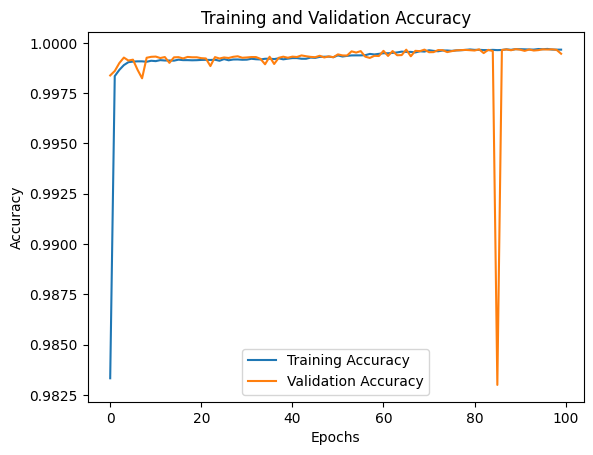

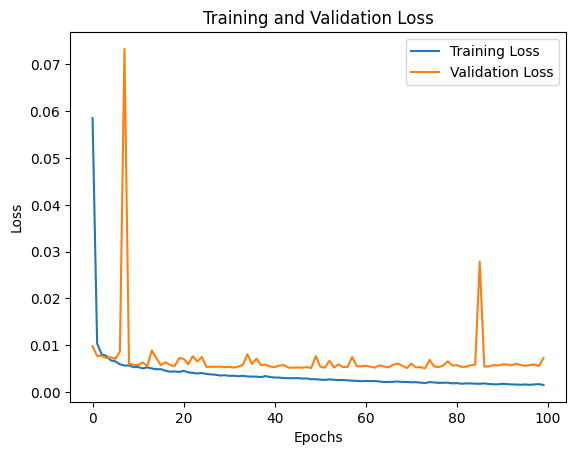

In [9]:
def plot_history(history):
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.show()
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

plot_history(history)

## Evaluate Model Performance

In [12]:
# !pip install scikit-learn
from sklearn.metrics import f1_score, confusion_matrix
y_pred = (mlp_model.predict(X_val) > 0.5).astype(int)
f1 = f1_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
print('F1 Score:', f1)
print('False Negative Rate:', fnr)
print('False Positive Rate:', fpr)

10805/10805 ━━━━━━━━━━━━━━━━━━━━ 6s 593us/step
F1 Score: 0.9994569205081838
False Negative Rate: 0.0009586564948977529
False Positive Rate: 0.00012747858939146357


## Save and Load Model

In [4]:
# mlp_model.save('mlp_binary_classification.h5')
loaded_model = tf.keras.models.load_model('mlp_binary_classification.h5')
loaded_model.summary()

2025-09-12 08:46:32.508922: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1100)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       110,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,203 (430.48 KB)

 Trainable params: 110,201 (430.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Test Model on Baseline Test Dataset
Now let's test the trained model on the baseline test dataset to evaluate its performance on unseen data.

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix
# Load baseline test dataset
X_test_baseline, y_test_baseline = load_dataset(DATASET_FOLDER + '/*-test.hdf5')
print('Baseline Test shape:', X_test_baseline.shape, y_test_baseline.shape)

# Predict on baseline test dataset
y_pred_baseline = (loaded_model.predict(X_test_baseline) > 0.5).astype(int)

# Calculate metrics for baseline test
f1_baseline = f1_score(y_test_baseline, y_pred_baseline)
cm_baseline = confusion_matrix(y_test_baseline, y_pred_baseline)
tn_baseline, fp_baseline, fn_baseline, tp_baseline = cm_baseline.ravel()
fnr_baseline = fn_baseline / (fn_baseline + tp_baseline) if (fn_baseline + tp_baseline) > 0 else 0
fpr_baseline = fp_baseline / (fp_baseline + tn_baseline) if (fp_baseline + tn_baseline) > 0 else 0

print('\n=== Baseline Test Dataset Results ===')
print('F1 Score:', f1_baseline)
print('False Negative Rate:', fnr_baseline)
print('False Positive Rate:', fpr_baseline)
print('Confusion Matrix:')
print(cm_baseline)

Baseline Test shape: (384147, 100, 11) (384147,)
12005/12005 ━━━━━━━━━━━━━━━━━━━━ 7s 590us/step
12005/12005 ━━━━━━━━━━━━━━━━━━━━ 7s 590us/step


NameError: name 'f1_score' is not defined

## Test Model on Manipulated Dataset
Now let's test the model on the manipulated dataset to see how well it performs against adversarial attacks.

In [ ]:
# Load manipulated test dataset
MANIPULATED_DATASET_FOLDER = '../DATASETS/MANIPULATED-PCAPS'
X_test_manipulated, y_test_manipulated = load_dataset(MANIPULATED_DATASET_FOLDER + '/*-manipulated-test.hdf5')
print('Manipulated Test shape:', X_test_manipulated.shape, y_test_manipulated.shape)

# Predict on manipulated test dataset
y_pred_manipulated = (loaded_model.predict(X_test_manipulated) > 0.5).astype(int)

# Calculate metrics for manipulated test
f1_manipulated = f1_score(y_test_manipulated, y_pred_manipulated)
cm_manipulated = confusion_matrix(y_test_manipulated, y_pred_manipulated)
tn_manipulated, fp_manipulated, fn_manipulated, tp_manipulated = cm_manipulated.ravel()
fnr_manipulated = fn_manipulated / (fn_manipulated + tp_manipulated) if (fn_manipulated + tp_manipulated) > 0 else 0
fpr_manipulated = fp_manipulated / (fp_manipulated + tn_manipulated) if (fp_manipulated + tn_manipulated) > 0 else 0

print('\n=== Manipulated Test Dataset Results ===')
print('F1 Score:', f1_manipulated)
print('False Negative Rate:', fnr_manipulated)
print('False Positive Rate:', fpr_manipulated)
print('Confusion Matrix:')
print(cm_manipulated)

## Comparison: Baseline vs Manipulated Test Results
Let's compare the model's performance between the baseline test dataset and the manipulated dataset to assess the impact of adversarial attacks.

In [ ]:
# Create comparison table
import pandas as pd

comparison_data = {
    'Metric': ['F1 Score', 'False Negative Rate', 'False Positive Rate', 'True Positives', 'True Negatives', 'False Positives', 'False Negatives'],
    'Baseline Test': [f1_baseline, fnr_baseline, fpr_baseline, tp_baseline, tn_baseline, fp_baseline, fn_baseline],
    'Manipulated Test': [f1_manipulated, fnr_manipulated, fpr_manipulated, tp_manipulated, tn_manipulated, fp_manipulated, fn_manipulated]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Difference'] = comparison_df['Manipulated Test'] - comparison_df['Baseline Test']
comparison_df['% Change'] = ((comparison_df['Manipulated Test'] - comparison_df['Baseline Test']) / comparison_df['Baseline Test'] * 100).round(2)

print('=== Performance Comparison ===')
print(comparison_df.to_string(index=False))

# Calculate performance degradation
f1_degradation = ((f1_baseline - f1_manipulated) / f1_baseline) * 100 if f1_baseline > 0 else 0
fnr_increase = ((fnr_manipulated - fnr_baseline) / fnr_baseline) * 100 if fnr_baseline > 0 else float('inf') if fnr_manipulated > 0 else 0

print(f'\n=== Key Insights ===')
print(f'F1 Score degradation: {f1_degradation:.2f}%')
print(f'False Negative Rate increase: {fnr_increase:.2f}%')
print(f'Model robustness: {"Poor" if f1_degradation > 20 else "Moderate" if f1_degradation > 10 else "Good"}')

In [ ]:
# Visualize the comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# F1 Score comparison
metrics = ['F1 Score', 'False Negative Rate', 'False Positive Rate']
baseline_values = [f1_baseline, fnr_baseline, fpr_baseline]
manipulated_values = [f1_manipulated, fnr_manipulated, fpr_manipulated]

x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, baseline_values, width, label='Baseline', alpha=0.8)
axes[0, 0].bar(x + width/2, manipulated_values, width, label='Manipulated', alpha=0.8)
axes[0, 0].set_xlabel('Metrics')
axes[0, 0].set_ylabel('Values')
axes[0, 0].set_title('Performance Metrics Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Confusion Matrix for Baseline
im1 = axes[0, 1].imshow(cm_baseline, interpolation='nearest', cmap=plt.cm.Blues)
axes[0, 1].set_title('Baseline Test Confusion Matrix')
tick_marks = np.arange(2)
axes[0, 1].set_xticks(tick_marks)
axes[0, 1].set_yticks(tick_marks)
axes[0, 1].set_xticklabels(['Benign', 'Malicious'])
axes[0, 1].set_yticklabels(['Benign', 'Malicious'])
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[0, 1].text(j, i, format(cm_baseline[i, j], 'd'),
                       ha="center", va="center", color="white" if cm_baseline[i, j] > cm_baseline.max() / 2 else "black")

# Confusion Matrix for Manipulated
im2 = axes[1, 0].imshow(cm_manipulated, interpolation='nearest', cmap=plt.cm.Reds)
axes[1, 0].set_title('Manipulated Test Confusion Matrix')
axes[1, 0].set_xticks(tick_marks)
axes[1, 0].set_yticks(tick_marks)
axes[1, 0].set_xticklabels(['Benign', 'Malicious'])
axes[1, 0].set_yticklabels(['Benign', 'Malicious'])
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, format(cm_manipulated[i, j], 'd'),
                       ha="center", va="center", color="white" if cm_manipulated[i, j] > cm_manipulated.max() / 2 else "black")

# Performance degradation visualization
degradation_metrics = ['F1 Score', 'Detection Rate', 'Precision']
baseline_perf = [f1_baseline, 1-fnr_baseline, tp_baseline/(tp_baseline+fp_baseline) if (tp_baseline+fp_baseline) > 0 else 0]
manipulated_perf = [f1_manipulated, 1-fnr_manipulated, tp_manipulated/(tp_manipulated+fp_manipulated) if (tp_manipulated+fp_manipulated) > 0 else 0]

x_deg = np.arange(len(degradation_metrics))
axes[1, 1].bar(x_deg - width/2, baseline_perf, width, label='Baseline', alpha=0.8, color='green')
axes[1, 1].bar(x_deg + width/2, manipulated_perf, width, label='Manipulated', alpha=0.8, color='red')
axes[1, 1].set_xlabel('Performance Metrics')
axes[1, 1].set_ylabel('Values')
axes[1, 1].set_title('Performance Degradation Analysis')
axes[1, 1].set_xticks(x_deg)
axes[1, 1].set_xticklabels(degradation_metrics, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()